In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Why Fraud Detection?

Fraud is a billion-dollar business and it is increasing every year. The PwC global economic crime survey of 2018[1] found that half (49 percent) of the 7,200 companies they surveyed had experienced fraud of some kind. This is an increase from the PwC 2016 study in which slightly more than a third of organizations surveyed (36%) had experienced economic crime.

In [ ]:
df = pd.read_csv("../data/train_transaction.csv")

In [3]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


This is binary classification task, where we need to predict **isFraud** field. Let's look at the distribution.

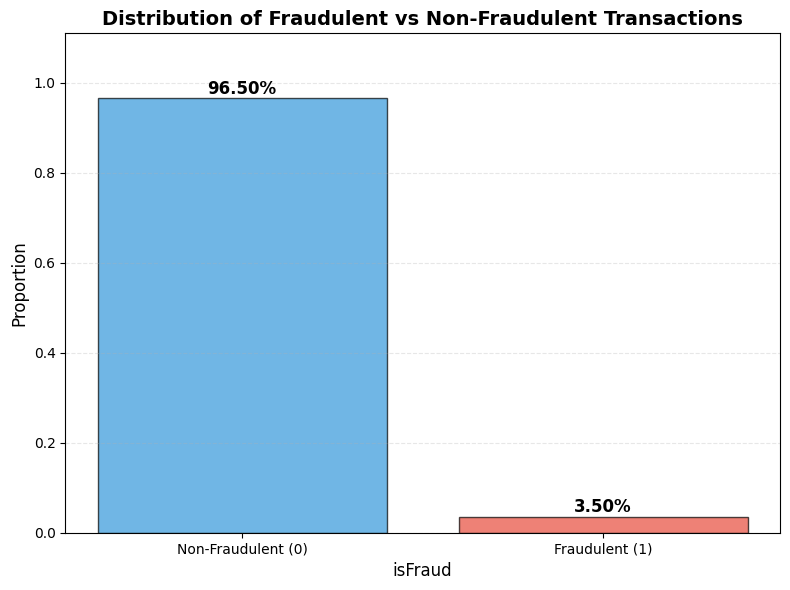

Non-Fraudulent: 96.50%
Fraudulent: 3.50%


In [8]:
# Plot fraud distribution
fraud_counts = df["isFraud"].value_counts()
fraud_proportions = fraud_counts / len(df)

plt.figure(figsize=(8, 6))
bars = plt.bar(fraud_proportions.index, fraud_proportions.values, 
               color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')

# Add value labels on bars
for i, (idx, val) in enumerate(fraud_proportions.items()):
    plt.text(idx, val + 0.01, f'{val:.2%}', ha='center', fontsize=12, fontweight='bold')

plt.xlabel('isFraud', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Non-Fraudulent (0)', 'Fraudulent (1)'])
plt.ylim(0, max(fraud_proportions.values) * 1.15)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Print summary
print(f"Non-Fraudulent: {fraud_proportions[0]:.2%}")
print(f"Fraudulent: {fraud_proportions[1]:.2%}")

We can clearly see that the dataset is extremely imbalanced. Only 3.5% of all transactions are fraudulent. Now let's look at the descriptions of the fields

### Categorical Features - Transaction

- ProductCD
- card1 - card6
- addr1, addr2
- P_emaildomain 
- R_emaildomain 
- M1 - M9

From the description and our dataframe, we can see that a lot of columns are anonymized, which is expected since this is real world data.

Another issue we can notice is that a lot of values in the dataframe are NaN. Let's investigate that.

Columns with missing values: 374

Top 15 columns with most missing values:
Column  Missing Count  Missing Percentage
 dist2         552913           93.628374
    D7         551623           93.409930
   D13         528588           89.509263
   D14         528353           89.469469
   D12         525823           89.041047
    D6         517353           87.606767
    D9         515614           87.312290
    D8         515614           87.312290
  V153         508595           86.123717
  V139         508595           86.123717
  V162         508595           86.123717
  V161         508595           86.123717
  V154         508595           86.123717
  V138         508595           86.123717
  V158         508595           86.123717


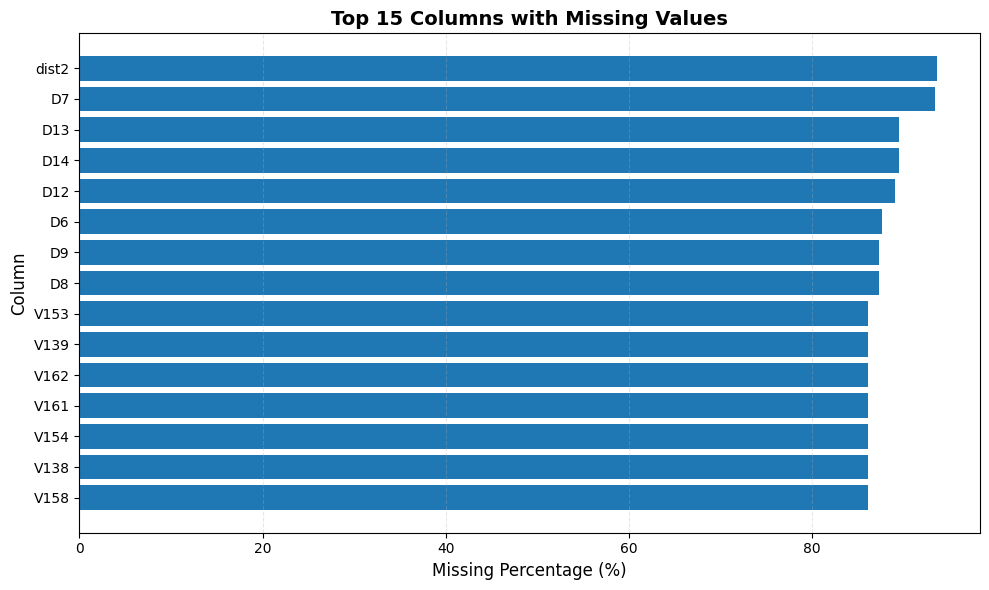

In [9]:
# Missing values analysis
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing Count': missing_counts.values,
    'Missing Percentage': missing_percentages.values
}).sort_values('Missing Percentage', ascending=False)

# Show columns with missing values
print(f"Columns with missing values: {len(missing_df[missing_df['Missing Count'] > 0])}")
print(f"\nTop 15 columns with most missing values:")
print(missing_df[missing_df['Missing Count'] > 0].head(15).to_string(index=False))

# Visualization
top_missing = missing_df[missing_df['Missing Count'] > 0].head(15)
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_missing)), top_missing['Missing Percentage'])
plt.yticks(range(len(top_missing)), top_missing['Column'])
plt.xlabel('Missing Percentage (%)', fontsize=12)
plt.ylabel('Column', fontsize=12)
plt.title('Top 15 Columns with Missing Values', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


Let's now investigate TransactionDT, since we can cleary see that it is not a datetime value.

In [11]:
# Investigate TransactionDT
print("TransactionDT Statistics:")
print(f"Min: {df['TransactionDT'].min():,}")
print(f"Max: {df['TransactionDT'].max():,}")
print(f"Range: {df['TransactionDT'].max() - df['TransactionDT'].min():,}")

# Calculate the range in different time units
range_val = df['TransactionDT'].max() - df['TransactionDT'].min()

print(f"\nIf TransactionDT is in SECONDS:")
print(f"  Range = {range_val / 60:.2f} minutes")
print(f"  Range = {range_val / 3600:.2f} hours")
print(f"  Range = {range_val / 86400:.2f} days")
print(f"  Range = {range_val / (86400 * 30):.2f} months (approx)")

print(f"\nIf TransactionDT is in MINUTES:")
print(f"  Range = {range_val / 60:.2f} hours")
print(f"  Range = {range_val / 1440:.2f} days")

print(f"\nIf TransactionDT is in HOURS:")
print(f"  Range = {range_val / 24:.2f} days")
print(f"  Range = {range_val / (24 * 365):.2f} years")

# Note: The minimum value starts at ~86400 which is 1 day in seconds
print(f"\n--- Analysis ---")
print(f"First value: {df['TransactionDT'].min():,} = {df['TransactionDT'].min() / 86400:.2f} days if seconds")
print(f"This suggests TransactionDT is likely in SECONDS, starting from some reference point")


TransactionDT Statistics:
Min: 86,400
Max: 15,811,131
Range: 15,724,731

If TransactionDT is in SECONDS:
  Range = 262078.85 minutes
  Range = 4367.98 hours
  Range = 182.00 days
  Range = 6.07 months (approx)

If TransactionDT is in MINUTES:
  Range = 262078.85 hours
  Range = 10919.95 days

If TransactionDT is in HOURS:
  Range = 655197.12 days
  Range = 1795.06 years

--- Analysis ---
First value: 86,400 = 1.00 days if seconds
This suggests TransactionDT is likely in SECONDS, starting from some reference point


We can understand from the analysis that TransactionDT is in seconds. Now let's look at transation amounts.

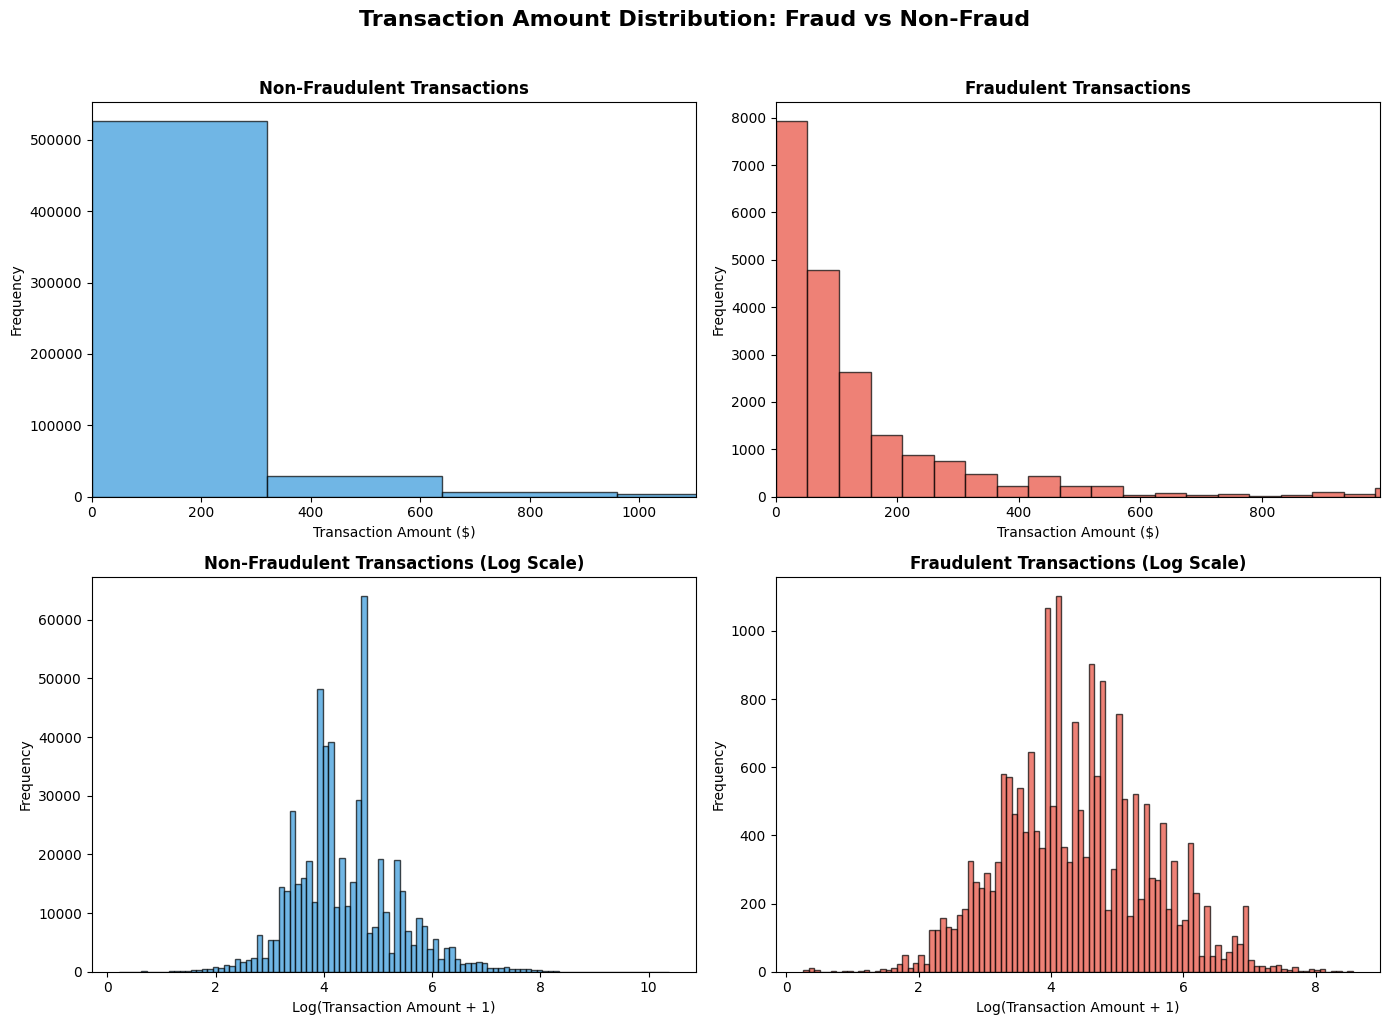

Transaction Amount Statistics:

Non-Fraudulent (n=569,877):
  Mean: $134.51, Median: $68.50
  Min: $0.25, Max: $31937.39

Fraudulent (n=20,663):
  Mean: $149.24, Median: $75.00
  Min: $0.29, Max: $5191.00


In [12]:
# Transaction Amount Distribution: Fraud vs Non-Fraud
fraud = df[df['isFraud'] == 1]['TransactionAmt']
non_fraud = df[df['isFraud'] == 0]['TransactionAmt']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Regular distribution - Non-Fraud
axes[0, 0].hist(non_fraud, bins=100, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Transaction Amount ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Non-Fraudulent Transactions', fontweight='bold')
axes[0, 0].set_xlim(0, non_fraud.quantile(0.99))  # Limit to 99th percentile for better visibility

# Plot 2: Regular distribution - Fraud
axes[0, 1].hist(fraud, bins=100, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Transaction Amount ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Fraudulent Transactions', fontweight='bold')
axes[0, 1].set_xlim(0, fraud.quantile(0.99))

# Plot 3: Log distribution - Non-Fraud
axes[1, 0].hist(np.log1p(non_fraud), bins=100, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Log(Transaction Amount + 1)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Non-Fraudulent Transactions (Log Scale)', fontweight='bold')

# Plot 4: Log distribution - Fraud
axes[1, 1].hist(np.log1p(fraud), bins=100, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Log(Transaction Amount + 1)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Fraudulent Transactions (Log Scale)', fontweight='bold')

plt.suptitle('Transaction Amount Distribution: Fraud vs Non-Fraud', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
print("Transaction Amount Statistics:")
print(f"\nNon-Fraudulent (n={len(non_fraud):,}):")
print(f"  Mean: ${non_fraud.mean():.2f}, Median: ${non_fraud.median():.2f}")
print(f"  Min: ${non_fraud.min():.2f}, Max: ${non_fraud.max():.2f}")

print(f"\nFraudulent (n={len(fraud):,}):")
print(f"  Mean: ${fraud.mean():.2f}, Median: ${fraud.median():.2f}")
print(f"  Min: ${fraud.min():.2f}, Max: ${fraud.max():.2f}")


Now let's look at non-anonimyzed categorical features

In [ ]:
# Card features overview
card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']

print("Card Features Overview:")
print("=" * 60)
for col in card_cols:
    unique_count = df[col].nunique()
    missing_pct = df[col].isnull().sum() / len(df) * 100
    dtype = df[col].dtype
    print(f"{col}: {unique_count:,} unique values | {missing_pct:.2f}% missing | dtype: {dtype}")

# Show sample values for each card column
print("\nSample values for each card column:")
print("-" * 60)
for col in card_cols:
    print(f"{col}: {df[col].dropna().unique()[:5]}")


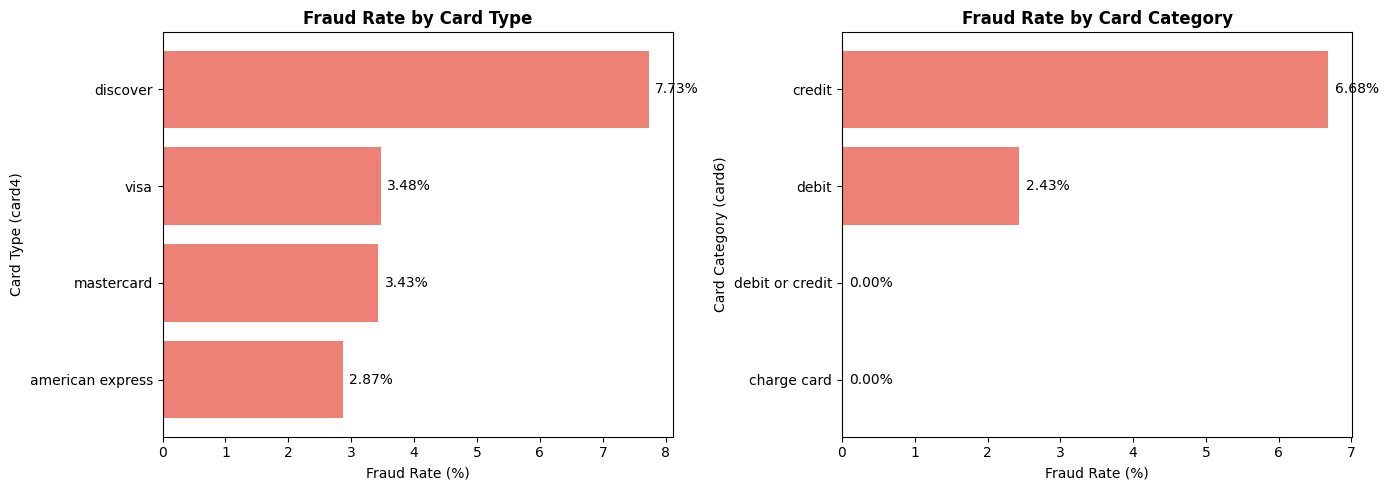


Card4 (Card Type) - Fraud Statistics:
                    sum   count  fraud_rate
card4                                      
american express    239    8328    2.869837
mastercard         6496  189217    3.433095
visa              13373  384767    3.475610
discover            514    6651    7.728161

Card6 (Card Category) - Fraud Statistics:
                   sum   count  fraud_rate
card6                                     
charge card          0      15    0.000000
debit or credit      0      30    0.000000
debit            10674  439938    2.426251
credit            9950  148986    6.678480


In [14]:
# Fraud rate by card4 (card type) and card6 (card category)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Card4 - Card Type (visa, mastercard, etc.)
card4_fraud = df.groupby('card4')['isFraud'].agg(['sum', 'count'])
card4_fraud['fraud_rate'] = card4_fraud['sum'] / card4_fraud['count'] * 100
card4_fraud = card4_fraud.sort_values('fraud_rate', ascending=True)

axes[0].barh(card4_fraud.index, card4_fraud['fraud_rate'], color='#e74c3c', alpha=0.7)
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_ylabel('Card Type (card4)')
axes[0].set_title('Fraud Rate by Card Type', fontweight='bold')
for i, (idx, row) in enumerate(card4_fraud.iterrows()):
    axes[0].text(row['fraud_rate'] + 0.1, i, f"{row['fraud_rate']:.2f}%", va='center', fontsize=10)

# Card6 - Card Category (credit, debit, etc.)
card6_fraud = df.groupby('card6')['isFraud'].agg(['sum', 'count'])
card6_fraud['fraud_rate'] = card6_fraud['sum'] / card6_fraud['count'] * 100
card6_fraud = card6_fraud.sort_values('fraud_rate', ascending=True)

axes[1].barh(card6_fraud.index, card6_fraud['fraud_rate'], color='#e74c3c', alpha=0.7)
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_ylabel('Card Category (card6)')
axes[1].set_title('Fraud Rate by Card Category', fontweight='bold')
for i, (idx, row) in enumerate(card6_fraud.iterrows()):
    axes[1].text(row['fraud_rate'] + 0.1, i, f"{row['fraud_rate']:.2f}%", va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print detailed stats
print("\nCard4 (Card Type) - Fraud Statistics:")
print(card4_fraud.to_string())
print("\nCard6 (Card Category) - Fraud Statistics:")
print(card6_fraud.to_string())


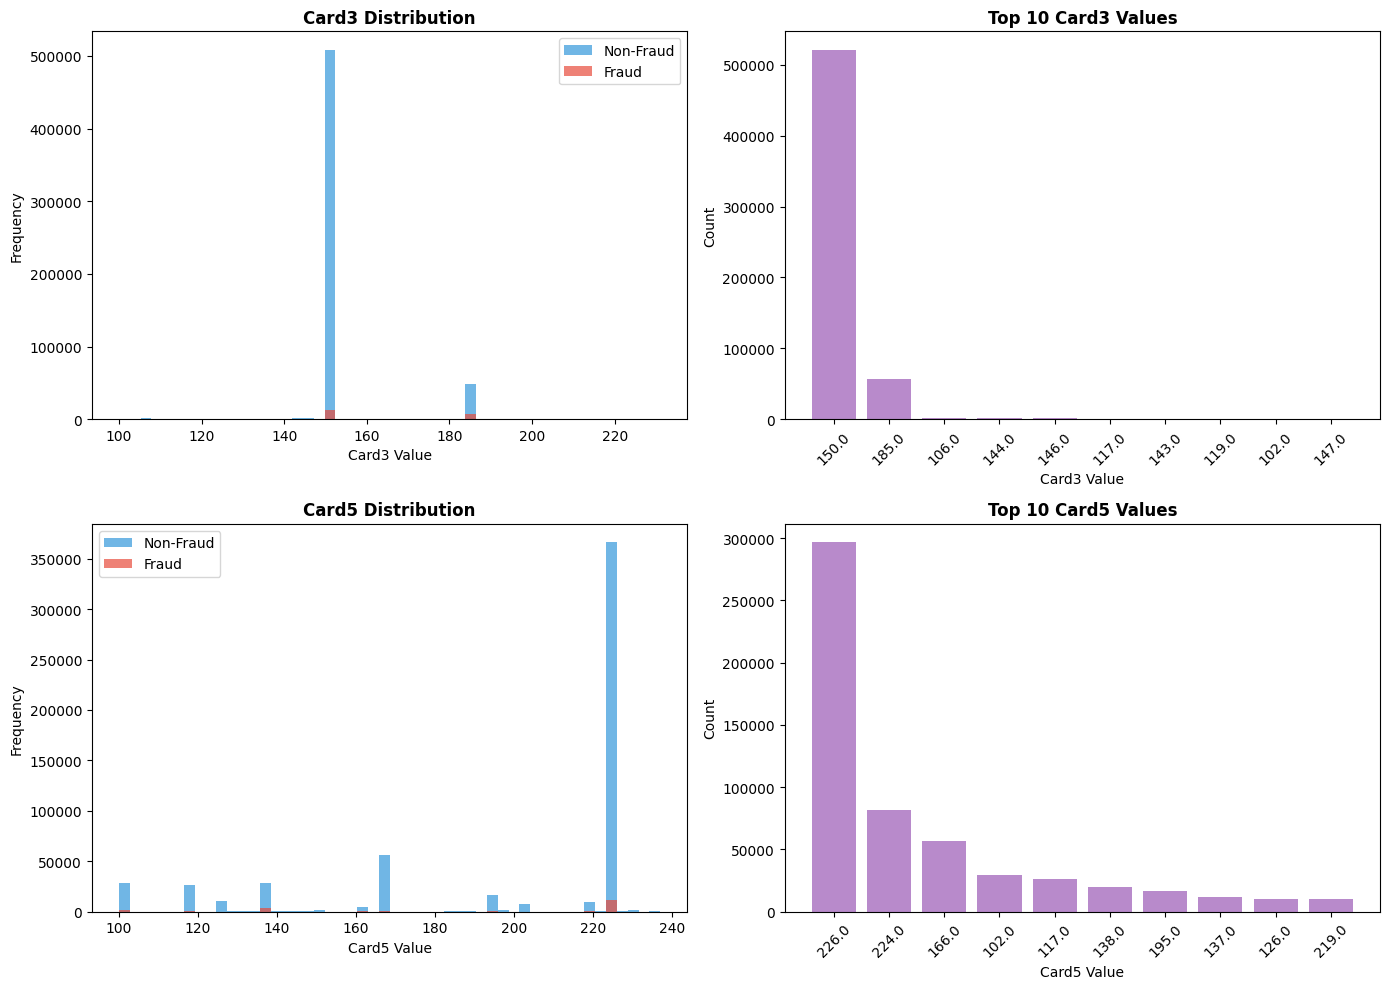

In [17]:
# Card3 and Card5 analysis (numerical card features)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Card3 distribution by fraud status
non_fraud_card3 = df[df['isFraud'] == 0]['card3'].dropna()
fraud_card3 = df[df['isFraud'] == 1]['card3'].dropna()

axes[0, 0].hist(non_fraud_card3, bins=50, color='#3498db', alpha=0.7, label='Non-Fraud')
axes[0, 0].hist(fraud_card3, bins=50, color='#e74c3c', alpha=0.7, label='Fraud')
axes[0, 0].set_xlabel('Card3 Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Card3 Distribution', fontweight='bold')
axes[0, 0].legend()

# Card3 value counts
card3_counts = df['card3'].value_counts().head(10)
axes[0, 1].bar(card3_counts.index.astype(str), card3_counts.values, color='#9b59b6', alpha=0.7)
axes[0, 1].set_xlabel('Card3 Value')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Top 10 Card3 Values', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# Card5 distribution by fraud status
non_fraud_card5 = df[df['isFraud'] == 0]['card5'].dropna()
fraud_card5 = df[df['isFraud'] == 1]['card5'].dropna()

axes[1, 0].hist(non_fraud_card5, bins=50, color='#3498db', alpha=0.7, label='Non-Fraud')
axes[1, 0].hist(fraud_card5, bins=50, color='#e74c3c', alpha=0.7, label='Fraud')
axes[1, 0].set_xlabel('Card5 Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Card5 Distribution', fontweight='bold')
axes[1, 0].legend()

# Card5 value counts
card5_counts = df['card5'].value_counts().head(10)
axes[1, 1].bar(card5_counts.index.astype(str), card5_counts.values, color='#9b59b6', alpha=0.7)
axes[1, 1].set_xlabel('Card5 Value')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Top 10 Card5 Values', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Card3 and Card5 likely represent numerical card attributes (possibly country/region codes)

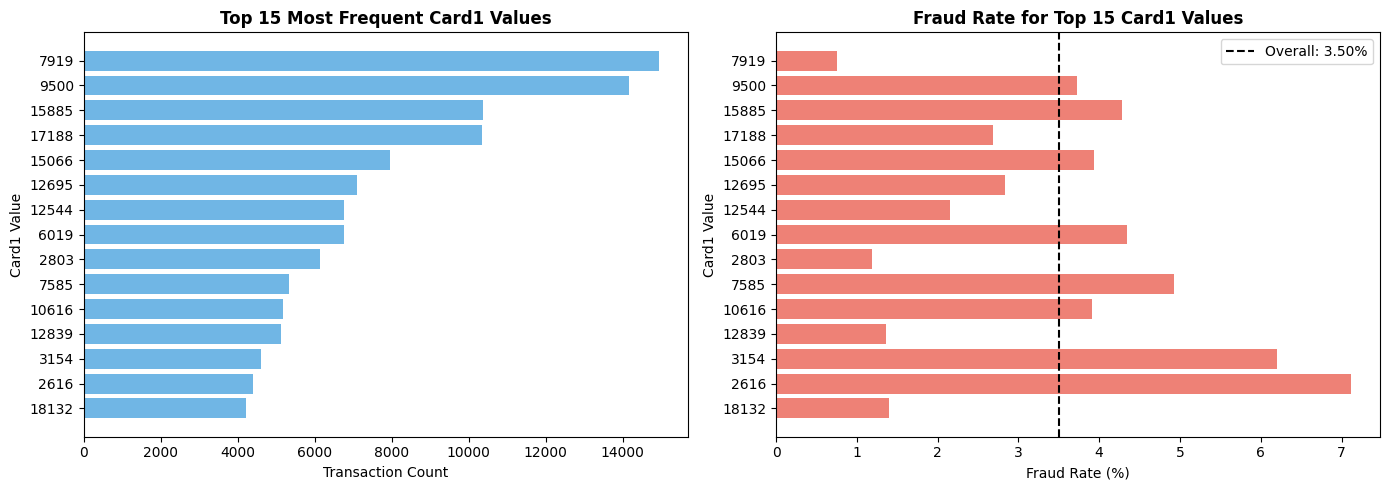


Card1 has 13,553 unique values
Top 15 values account for 19.20% of all transactions


In [16]:
# Card1 analysis - most frequent values and their fraud rates
card1_stats = df.groupby('card1')['isFraud'].agg(['sum', 'count'])
card1_stats['fraud_rate'] = card1_stats['sum'] / card1_stats['count'] * 100
card1_stats = card1_stats.sort_values('count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 15 most frequent card1 values
top_card1 = card1_stats.head(15)
axes[0].barh(range(len(top_card1)), top_card1['count'], color='#3498db', alpha=0.7)
axes[0].set_yticks(range(len(top_card1)))
axes[0].set_yticklabels(top_card1.index)
axes[0].set_xlabel('Transaction Count')
axes[0].set_ylabel('Card1 Value')
axes[0].set_title('Top 15 Most Frequent Card1 Values', fontweight='bold')
axes[0].invert_yaxis()

# Fraud rate for top 15 card1 values
axes[1].barh(range(len(top_card1)), top_card1['fraud_rate'], color='#e74c3c', alpha=0.7)
axes[1].set_yticks(range(len(top_card1)))
axes[1].set_yticklabels(top_card1.index)
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_ylabel('Card1 Value')
axes[1].set_title('Fraud Rate for Top 15 Card1 Values', fontweight='bold')
axes[1].invert_yaxis()
axes[1].axvline(x=df['isFraud'].mean() * 100, color='black', linestyle='--', label=f'Overall: {df["isFraud"].mean()*100:.2f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nCard1 has {df['card1'].nunique():,} unique values")
print(f"Top 15 values account for {top_card1['count'].sum() / len(df) * 100:.2f}% of all transactions")


## ProductCD and Email Domain Analysis

Now let's investigate:
- **ProductCD**: Product code (anonymized product category)
- **P_emaildomain**: Purchaser email domain
- **R_emaildomain**: Recipient email domain


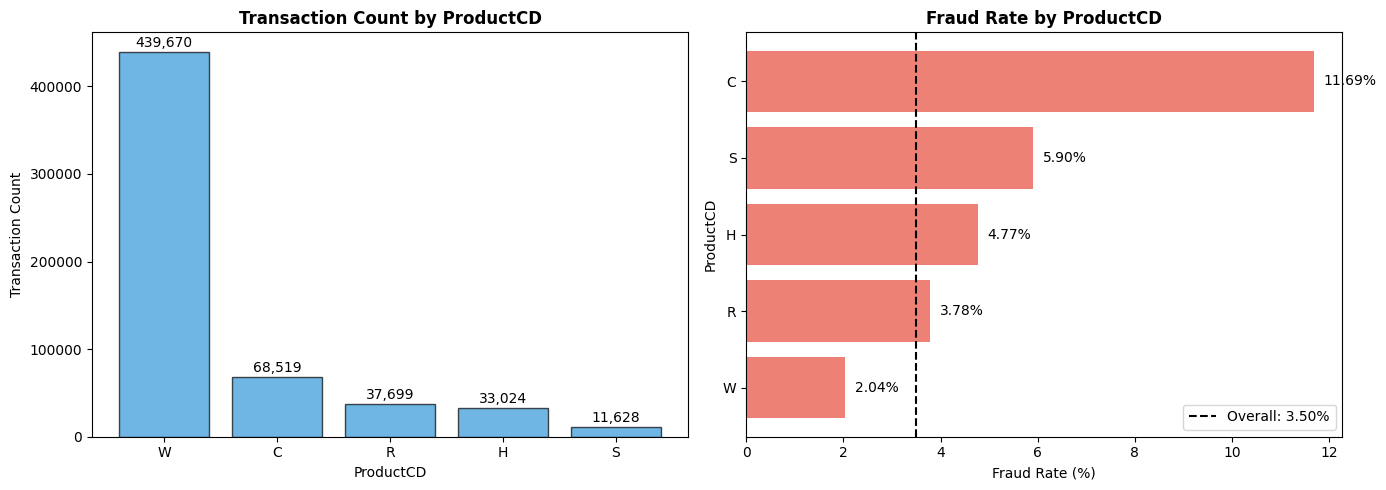

ProductCD Fraud Statistics:
            sum   count  fraud_rate
ProductCD                          
W          8969  439670    2.039939
R          1426   37699    3.782594
H          1574   33024    4.766231
S           686   11628    5.899553
C          8008   68519   11.687269


In [18]:
# ProductCD Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ProductCD distribution
product_counts = df['ProductCD'].value_counts()
axes[0].bar(product_counts.index, product_counts.values, color='#3498db', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('ProductCD')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Transaction Count by ProductCD', fontweight='bold')
for i, (idx, val) in enumerate(product_counts.items()):
    axes[0].text(i, val + 5000, f'{val:,}', ha='center', fontsize=10)

# Fraud rate by ProductCD
product_fraud = df.groupby('ProductCD')['isFraud'].agg(['sum', 'count'])
product_fraud['fraud_rate'] = product_fraud['sum'] / product_fraud['count'] * 100
product_fraud = product_fraud.sort_values('fraud_rate', ascending=True)

axes[1].barh(product_fraud.index, product_fraud['fraud_rate'], color='#e74c3c', alpha=0.7)
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_ylabel('ProductCD')
axes[1].set_title('Fraud Rate by ProductCD', fontweight='bold')
axes[1].axvline(x=df['isFraud'].mean() * 100, color='black', linestyle='--', label=f'Overall: {df["isFraud"].mean()*100:.2f}%')
for i, (idx, row) in enumerate(product_fraud.iterrows()):
    axes[1].text(row['fraud_rate'] + 0.2, i, f"{row['fraud_rate']:.2f}%", va='center', fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.show()

print("ProductCD Fraud Statistics:")
print(product_fraud.to_string())


Email Domain Overview:
P_emaildomain: 59 unique values | 15.99% missing
R_emaildomain: 60 unique values | 76.75% missing


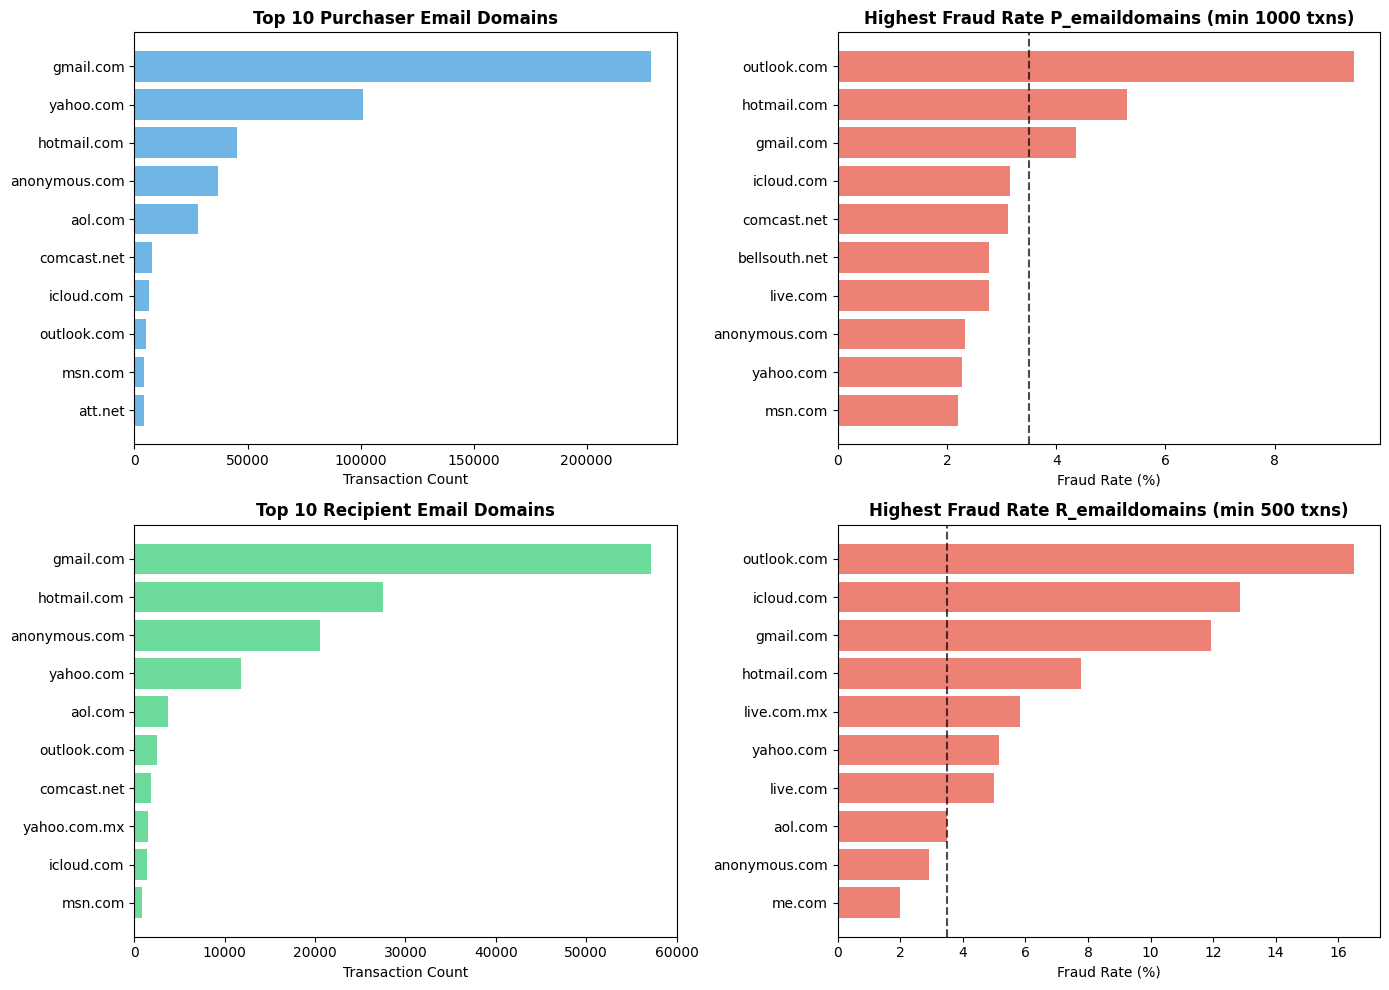

In [19]:
# Email Domain Analysis
print("Email Domain Overview:")
print("=" * 60)
print(f"P_emaildomain: {df['P_emaildomain'].nunique()} unique values | {df['P_emaildomain'].isnull().sum() / len(df) * 100:.2f}% missing")
print(f"R_emaildomain: {df['R_emaildomain'].nunique()} unique values | {df['R_emaildomain'].isnull().sum() / len(df) * 100:.2f}% missing")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top 10 P_emaildomain by count
p_email_counts = df['P_emaildomain'].value_counts().head(10)
axes[0, 0].barh(range(len(p_email_counts)), p_email_counts.values, color='#3498db', alpha=0.7)
axes[0, 0].set_yticks(range(len(p_email_counts)))
axes[0, 0].set_yticklabels(p_email_counts.index)
axes[0, 0].set_xlabel('Transaction Count')
axes[0, 0].set_title('Top 10 Purchaser Email Domains', fontweight='bold')
axes[0, 0].invert_yaxis()

# Top 10 P_emaildomain fraud rate
p_email_fraud = df.groupby('P_emaildomain')['isFraud'].agg(['sum', 'count'])
p_email_fraud['fraud_rate'] = p_email_fraud['sum'] / p_email_fraud['count'] * 100
# Filter to domains with at least 1000 transactions
p_email_fraud_filtered = p_email_fraud[p_email_fraud['count'] >= 1000].sort_values('fraud_rate', ascending=False).head(10)

axes[0, 1].barh(range(len(p_email_fraud_filtered)), p_email_fraud_filtered['fraud_rate'], color='#e74c3c', alpha=0.7)
axes[0, 1].set_yticks(range(len(p_email_fraud_filtered)))
axes[0, 1].set_yticklabels(p_email_fraud_filtered.index)
axes[0, 1].set_xlabel('Fraud Rate (%)')
axes[0, 1].set_title('Highest Fraud Rate P_emaildomains (min 1000 txns)', fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].axvline(x=df['isFraud'].mean() * 100, color='black', linestyle='--', alpha=0.7)

# Top 10 R_emaildomain by count
r_email_counts = df['R_emaildomain'].value_counts().head(10)
axes[1, 0].barh(range(len(r_email_counts)), r_email_counts.values, color='#2ecc71', alpha=0.7)
axes[1, 0].set_yticks(range(len(r_email_counts)))
axes[1, 0].set_yticklabels(r_email_counts.index)
axes[1, 0].set_xlabel('Transaction Count')
axes[1, 0].set_title('Top 10 Recipient Email Domains', fontweight='bold')
axes[1, 0].invert_yaxis()

# Top 10 R_emaildomain fraud rate
r_email_fraud = df.groupby('R_emaildomain')['isFraud'].agg(['sum', 'count'])
r_email_fraud['fraud_rate'] = r_email_fraud['sum'] / r_email_fraud['count'] * 100
r_email_fraud_filtered = r_email_fraud[r_email_fraud['count'] >= 500].sort_values('fraud_rate', ascending=False).head(10)

axes[1, 1].barh(range(len(r_email_fraud_filtered)), r_email_fraud_filtered['fraud_rate'], color='#e74c3c', alpha=0.7)
axes[1, 1].set_yticks(range(len(r_email_fraud_filtered)))
axes[1, 1].set_yticklabels(r_email_fraud_filtered.index)
axes[1, 1].set_xlabel('Fraud Rate (%)')
axes[1, 1].set_title('Highest Fraud Rate R_emaildomains (min 500 txns)', fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].axvline(x=df['isFraud'].mean() * 100, color='black', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
